In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.ar_model import AutoReg

# Série temporal de exemplo
dados = pd.Series([1, 3, 2, 5, 8, 7, 9, 12, 10, 15])

# Calculando a autocorrelação com diferentes lags
lag = 1
autocorr = dados.autocorr(lag=lag)
print(f"Autocorrelação (lag {lag}): {autocorr}")

lag = 5
autocorr = dados.autocorr(lag=lag)
print(f"Autocorrelação (lag {lag}): {autocorr}")

lag = 8
autocorr = dados.autocorr(lag=lag)
print(f"Autocorrelação (lag {lag}): {autocorr}")

Autocorrelação (lag 1): 0.8317677196382274
Autocorrelação (lag 5): 0.7858412257336472
Autocorrelação (lag 8): 0.9999999999999999


# SEGUNDO TESTE

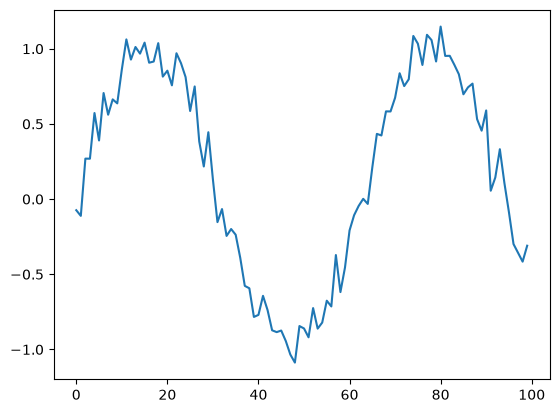

In [44]:
# nova série temporal
t = np.arange(100)
serie = np.sin(t * 0.1) + np.random.normal(0, 0.1, 100)
plt.plot(serie)

# GRÁFICO DE AUTO CORRELAÇÃO

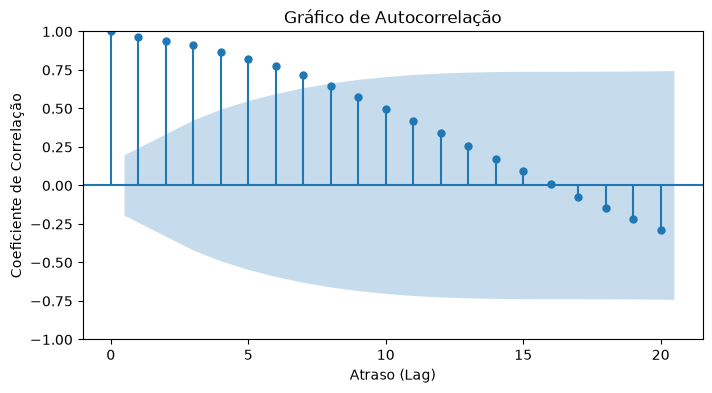

In [45]:
# Plota a Função de Autocorrelação (ACF)
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(serie, lags=20, ax=ax)

plt.title("Gráfico de Autocorrelação")
plt.xlabel("Atraso (Lag)")
plt.ylabel("Coeficiente de Correlação")
plt.show()

# ENCONTRA O MELHOR LAG USANDO AUTO CORRELAÇÃO

In [ ]:
from sklearn.metrics import mean_squared_error

dados1 =  pd.Series([1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4])
dados2 = pd.Series( np.sin(np.arange(100) * 0.1) + np.random.normal(0, 0.1, 100) )
dados3 = pd.Series( pd.read_csv('../AirPassengers.csv')['#Passengers'].values)

def max_size_treino(size_data, lag):
    ponto_corte = round(size_data* 0.8)
    nobs = size_data - 2*lag
    if(lag > nobs):
        print('Não foi possivel usar o LAG definido para o treinamento devido seu alto valor')
        return -1
    return ponto_corte

def testa_lag(dados, lag):
    ponto_corte = max_size_treino(len(dados) , lag)
    if ponto_corte == -1: return -1, -1
    dados_treino = dados[:ponto_corte]
    dados_teste = dados[ponto_corte:]
    modelo = AutoReg(dados_treino, lag).fit()
    X_pred = modelo.predict(start=len(dados_treino), end=len(dados_treino)+len(dados_teste)-1)
    MSE = mean_squared_error(dados_teste, X_pred)
    RMSE = np.sqrt(MSE)
    return modelo.aic, RMSE
    

In [168]:
# calcula manualmente todas as opções de lags usando autocorr
def testa_todas_autocorr(serie):
    maior_autocorr = -1
    melhor_lag = -1
    for lag in range(1, len(serie)-2):
        autocorr = serie.autocorr(lag=lag)
        if(autocorr > maior_autocorr):
            maior_autocorr = autocorr
            melhor_lag = lag
    
    aic, erro = testa_lag(serie, melhor_lag)
    print(f'Melhor LAG: {melhor_lag}: CORR: {maior_autocorr:.4f} AIC: {aic:.2f} ERRO: {erro:.4f}')

testa_todas_autocorr(dados1)
testa_todas_autocorr(dados2)
testa_todas_autocorr(dados3)

Melhor LAG: 4: CORR: 1.0000 AIC: -377.61 ERRO: 0.0000
Melhor LAG: 1: CORR: 0.9745 AIC: -69.29 ERRO: 0.8281
Melhor LAG: 12: CORR: 0.9905 AIC: 823.99 ERRO: 43.2553


In [169]:
# calcula manualmente a auto correlação usando correlação de Pearson (testa todas as opções de lag)
def find_best_lag(dados):
    # Subtrai a media dos valores
    dados_centrados = dados - np.mean(dados)
    # Calcula a correlação de todos com todos
    correlacao = np.correlate(dados_centrados, dados_centrados, mode="full")
    # Considera apenas a segunda metade (pois é uma copia da outra metade)
    acf = correlacao[len(correlacao) // 2 :]
    # Ignora o lag 0 (que é do indice 0, que é sempre 1 pq ñ tem nenhum dado anterior) e pega o índice de maior correlação
    melhor_lag = np.argmax(acf[1:]) + 1 # argmax devolte o indice que tem o maior valor, aí soma 1 pra ter o lag desejado

    aic, erro = testa_lag(dados, melhor_lag)
    print(f'Melhor LAG: {melhor_lag}: CORR: {dados.autocorr(lag=melhor_lag):.4f} AIC: {aic:.2f} ERRO: {erro:.4f}')

find_best_lag(dados1)
find_best_lag(dados2)
find_best_lag(dados3)

Melhor LAG: 4: CORR: 1.0000 AIC: -377.61 ERRO: 0.0000
Melhor LAG: 1: CORR: 0.9745 AIC: -69.29 ERRO: 0.8281
Melhor LAG: 1: CORR: 0.9602 AIC: 1078.05 ERRO: 88.6774


In [175]:
from statsmodels.tsa.stattools import acf

# faz o mesmo acima de forma mais limpa
def find_best_lag(dados):
    correlacao = acf(dados, nlags= len(dados)-1 )
    valores_acf = correlacao[len(correlacao) // 2 :]
    melhor_lag = np.argmax(valores_acf[1:]) + 1 # argmax devolte o indice que tem o maior valor, aí soma 1 pra ter o lag desejado
    
    aic, erro = testa_lag(dados, melhor_lag)
    print(f'Melhor LAG: {melhor_lag}: CORR: {valores_acf[melhor_lag]:.4f} AIC: {aic:.2f} ERRO: {erro:.4f}')

find_best_lag(dados1)
find_best_lag(dados2)
find_best_lag(dados3)

Melhor LAG: 2: CORR: 0.3333 AIC: 27.46 ERRO: 1.1967
Melhor LAG: 11: CORR: 0.2310 AIC: -88.72 ERRO: 0.1227
Não foi possivel usar o LAG definido para o treinamento devido seu alto valor
Melhor LAG: 71: CORR: -0.0124 AIC: -1.00 ERRO: -1.0000
